# Agent.py

In [ ]:
import os
from langchain.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from dotenv import load_dotenv

load_dotenv()


# ============ ИНСТРУМЕНТЫ ============
@tool
def analyze_audience(niche: str) -> str:
    """Анализирует целевую аудиторию по нише (фитнес, IT, handmade, b2b, кулинария)"""
    audiences = {
        "фитнес": "ЦА: женщины 25-35 лет, интересы: здоровье, спорт. Боли: лишний вес, мотивация. Платформы: Instagram, TikTok",
        "it": "ЦА: 20-30 лет, интересы: программирование, карьера. Боли: смена профессии. Платформы: Telegram, YouTube",
        "handmade": "ЦА: женщины 30-45 лет, интересы: рукоделие, подарки. Боли: нехватка времени. Платформы: Pinterest, Instagram",
        "b2b": "ЦА: 30-50 лет, интересы: бизнес, автоматизация. Боли: неэффективность. Платформы: LinkedIn",
        "кулинария": "ЦА: женщины 25-45 лет, интересы: рецепты, семья. Боли: нехватка идей. Платформы: YouTube, Instagram"
    }
    return audiences.get(niche.lower(), f"Ниша '{niche}' не найдена. Доступные: фитнес, IT, handmade, b2b, кулинария")


@tool
def generate_post_ideas(theme: str) -> str:
    """Генерирует идеи постов по теме (запуск, вовлечение, продажи, экспертность)"""
    ideas = {
        "запуск": "1) Тизер с обратным отсчетом\n2) Инструкция по использованию\n3) Закулисье создания продукта",
        "вовлечение": "1) Опрос: какую функцию хотите?\n2) Челлендж на 30 дней\n3) Конкурс с призами",
        "продажи": "1) Скидка 20% первым покупателям\n2) Видео-отзыв клиента\n3) Ограниченное предложение",
        "экспертность": "1) Кейс: история успеха клиента\n2) 5 трендов индустрии\n3) Разбор ошибок новичков"
    }
    return ideas.get(theme.lower(), f"Тема '{theme}' не найдена. Доступные: запуск, вовлечение, продажи, экспертность")


# ============ АГЕНТ ============
SYSTEM_PROMPT = """Ты — профессиональный маркетолог.
Помогаешь с анализом ЦА, идеями для контента и маркетинговыми стратегиями.
Используй инструменты для получения данных.
Если вопрос НЕ про маркетинг — отвечай только: "Команда неизвестна"
Отвечай кратко, по делу."""


class MarketingAgent:
    def __init__(self):
        self.llm = ChatGroq(
            model="llama-3.1-8b-instant",
            temperature=0,
            api_key=os.getenv("GROQ_API_KEY")
        )

    def run(self, question: str) -> str:
        question_lower = question.lower()

        marketing_keywords = ["ца", "аудитор", "контент", "пост", "идеи", "маркетинг",
                              "фитнес", "it", "handmade", "b2b", "кулинар",
                              "запуск", "вовлечение", "продажи", "экспертность", "образован"]

        if not any(keyword in question_lower for keyword in marketing_keywords):
            return "Команда неизвестна"

        result = ""

        if "ца" in question_lower or "аудитор" in question_lower:
            for niche in ["фитнес", "it", "handmade", "b2b", "кулинария"]:
                if niche in question_lower:
                    result = analyze_audience.invoke({"niche": niche})
                    break

        if "пост" in question_lower or "контент" in question_lower or "идеи" in question_lower:
            for theme in ["запуск", "вовлечение", "продажи", "экспертность"]:
                if theme in question_lower:
                    result = generate_post_ideas.invoke({"theme": theme})
                    break

        if result:
            messages = [
                SystemMessage(content=SYSTEM_PROMPT),
                HumanMessage(content=f"Данные: {result}\n\nВопрос: {question}\n\nДай краткий совет.")
            ]
            response = self.llm.invoke(messages)
            return f"{result}\n\n{response.content}"

        messages = [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=question)
        ]
        response = self.llm.invoke(messages)
        return response.content


# ============ ЭКСПОРТИРУЕМЫЕ ФУНКЦИИ ДЛЯ API ============
def create_agent():
    """Создает и возвращает экземпляр агента"""
    return MarketingAgent()


def ask(question: str, agent_executor) -> str:
    """Задает вопрос агенту (совместимость с API)"""
    return agent_executor.run(question)


# ============ ТЕСТ (для прямого запуска agent.py) ============
if __name__ == "__main__":
    agent = create_agent()
    print(ask("Проанализируй ЦА для фитнеса", agent))
    print("\n" + "=" * 50 + "\n")
    print(ask("Дай идеи для постов про запуск продукта", agent))
    print("\n" + "=" * 50 + "\n")
    print(ask("Какая погода завтра?", agent))


# App.py

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
from agent import create_agent, ask
from dotenv import load_dotenv

load_dotenv()

app = FastAPI(title="Marketing Agent")
agent_executor = create_agent()

class ChatRequest(BaseModel):
    message: str
    session_id: str = "default"

class ChatResponse(BaseModel):
    response: str

@app.post("/generate", response_model=ChatResponse)
async def generate(req: ChatRequest):
    response = ask(req.message, agent_executor)
    return ChatResponse(response=response)

if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)

# Результат работы

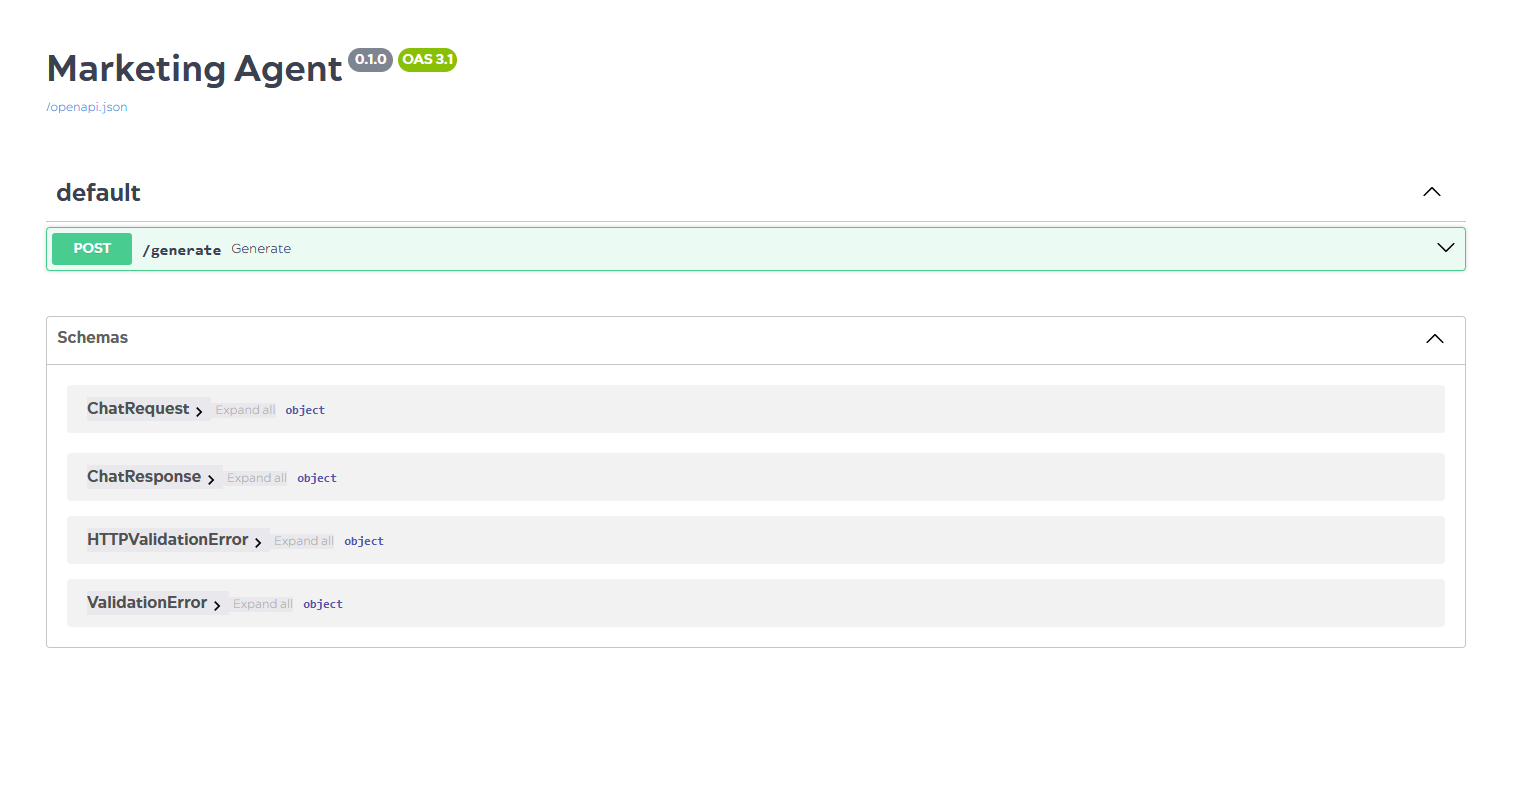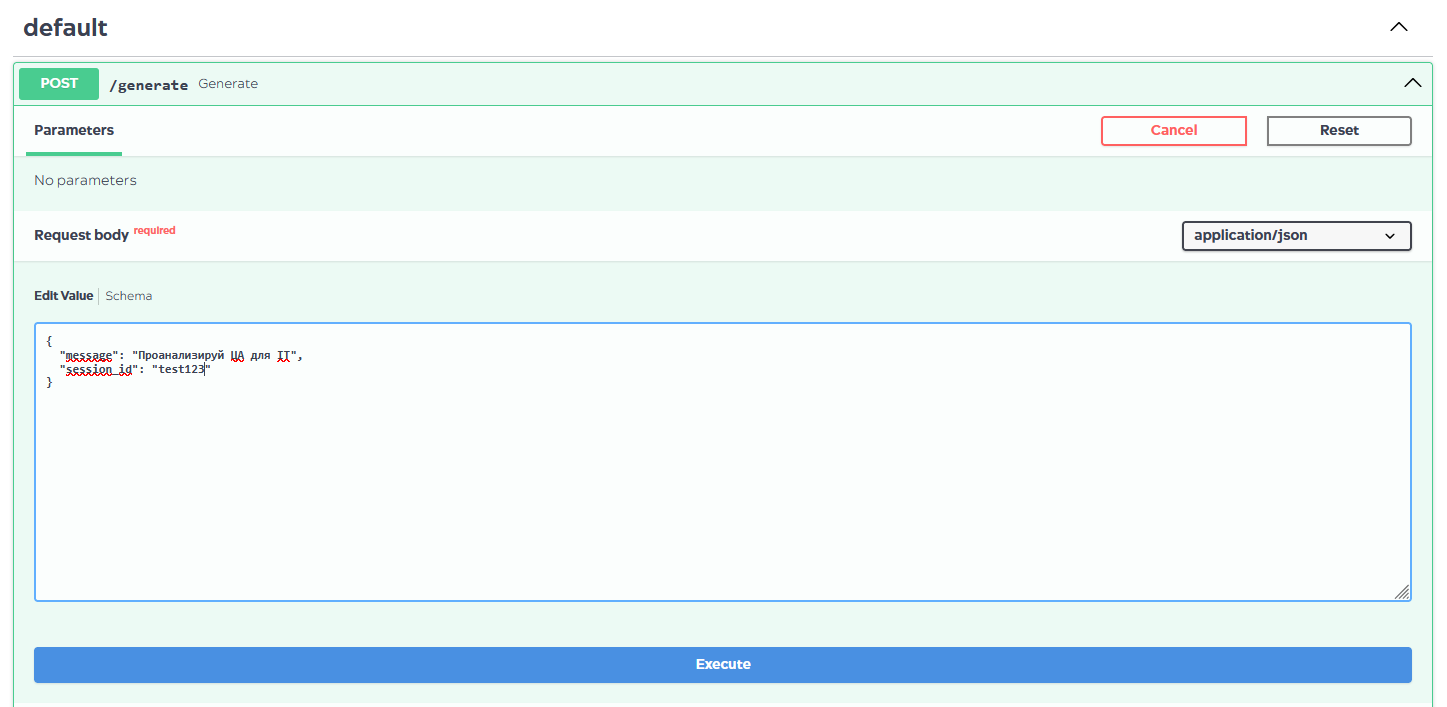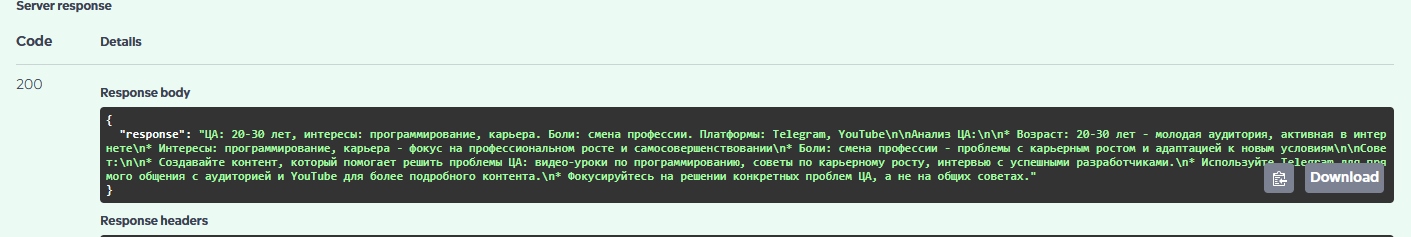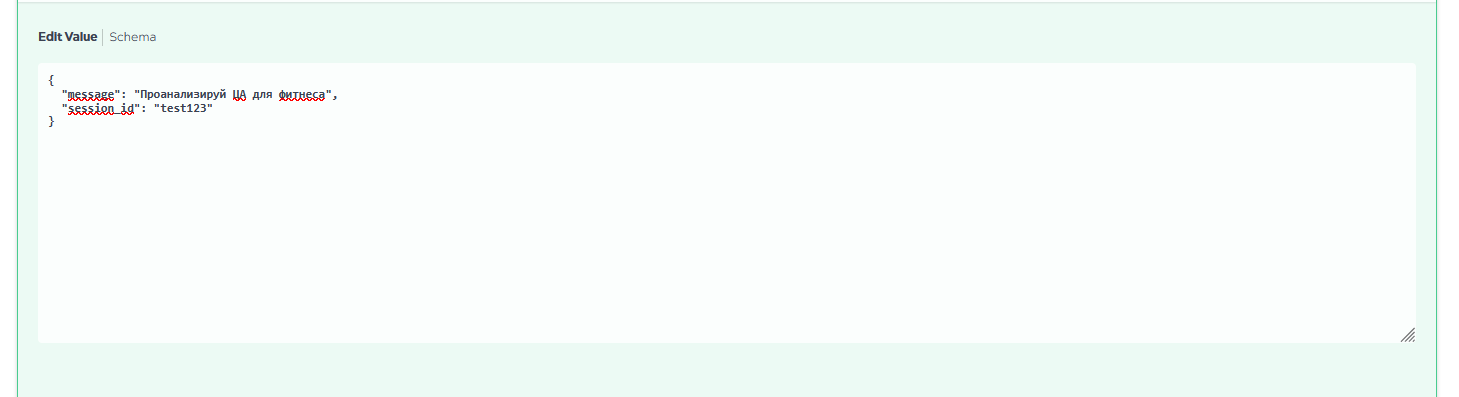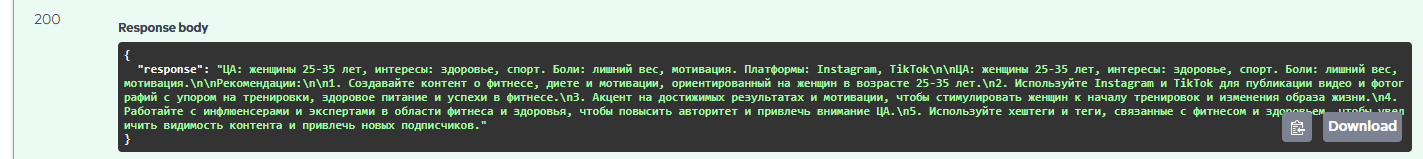